In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Comment Category Prediction Challenge

## Objective

The goal of this project is to build a machine learning model that predicts the **category label** of user comments.

The dataset contains:
- Text data (`comment`)
- Engagement features (`upvote`, `downvote`)
- Emoticon counts
- Demographic attributes (`race`, `religion`, `gender`)
- Boolean feature (`disability`)
- Timestamp (`created_date`)

### 0. *Dummy Submission*

Before performing any modeling, a dummy submission is created.

This confirms that:
- The dataset loads correctly.
- Submission format is valid.
- Kaggle accepts predictions.

In [2]:
'''#Dummy submission to the competition

X = train.drop(columns=['label'])
y = train['label']

from sklearn.dummy import DummyClassifier
dummy_model = DummyClassifier(strategy = 'most_frequent')
dummy_model.fit(X,y)
dummy_pred = dummy_model.predict(test)

sample['label'] = dummy_pred
sample.to_csv('submission.csv',index = False)
'''

"#Dummy submission to the competition\n\nX = train.drop(columns=['label'])\ny = train['label']\n\nfrom sklearn.dummy import DummyClassifier\ndummy_model = DummyClassifier(strategy = 'most_frequent')\ndummy_model.fit(X,y)\ndummy_pred = dummy_model.predict(test)\n\nsample['label'] = dummy_pred\nsample.to_csv('submission.csv',index = False)\n"

- The **DummyClassifier** predicts the **most frequent class** for all samples.
- This acts as a **baseline reference.**
- Any real model must perform **better than dummy performance.**

### 1. *Loading The Dataset*

In this competition we have three CSV files,
- **train.csv**  - contains `features` and the `target` label.
- **test.csv**   - contains `only features` and has `no label`.
- **Sample.csv** - shows the required submission format.

In [3]:
# Load training, test, and sample submission files
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

### *Shape of the dataset*


Understanding dataset size helps estimate model complexity.
- Number of rows (observations)
- Number of columns (features)

In [4]:
print("Shape of the training dataset :",train.shape)
print("Shape of the test dataset :", test.shape)
print("Shape of the Sample Submission :", sample.shape)

Shape of the training dataset : (198000, 15)
Shape of the test dataset : (102000, 14)
Shape of the Sample Submission : (102000, 2)


- Training dataset has **1,98,000 rows and 15 columns** (features + target variable).
- Test dataset has **1,02,000 rows and 14 columns** (only features).
- The missing column in the test set is the target variable (`label`).

The test dataset does not contain the **target column** (`label`), which confirms this is a **supervised learning problem.**

### *Column Names*

This step ensures feature consistency between train and test datasets.

In [5]:
print("Training Columns: \n",train.columns)
print("\nTest Columns: \n", test.columns)

Training Columns: 
 Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

Test Columns: 
 Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment'],
      dtype='object')


- All feature columns match between train and test datasets.
- Only the training dataset contains the **target variable** `label` column.
- This ensures the model can be trained and applied correctly.

### *Feature and Target Separation*

In [6]:
print("Feature List: \n", list(train.columns[:-1]))
print("Target Variable: ",[train.columns[-1]])

Feature List: 
 ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment']
Target Variable:  ['label']


- All columns except `label` are treated as **input features (independent variables)**.
- The `label` column represents the **target variable (dependent variable)**.
- This confirms **multi-class classification.**

### *Preview Sample Rows*
Viewing a few rows helps verify whether the data is loaded correctly and ensures there are no visible corruption or formatting issues.

In [7]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


- The training dataset contains both **feature variables** and the **target variable (`label`)**.
- It includes metadata such as `created_date` and `post_id`.
- Engagement-related features like `upvote`,`downvote`, and `emoticon counts` are present.
- Demographic features such as `race`,`religion`, and `gender` contain missing values (`NaN`).
- the `comment` column contains textual data that will likely require preprocessing.
- The `label` column represents the target variable for prediction.

In [8]:
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


- The test dataset contains the same feature columns as the training dataset.
- The **`label` column is not present**, as it needs to be predicted.
- The structure appears consistent with the training dataset.
- Missing values (`NaN`) are observed in similar columns.
- Text data in the `comment` column will require the same preprocessing steps applied to the training data.

### *Sample Submission Format*

In [9]:
#Load the sample submission format
sample.head()

,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


- Submission file contains two columns: `ID` and `label`.
- Model predictions must be written in this format for Kaggle Submission.

Overall, the datasets appear properly loaded with consistent structure and no visible formating issues.

### 2. *Exploratory Data Analysis*

**Exploratory Data Analysis (EDA)** is performed to understand the structure, quality and patterns in the dataset before building any model.

It helps identify:
- Data Structure
- Missing Values
- Feature Distributions
- Class (`Target Variable`) Imbalance
- Potential Preprocessing Requirements

Understanding these aspects ensures informed model design.

### *Dataset Structure Overview*

The `train.info()` output provides a summary of the dataset's structure, including the number of rows, columns, data types, and missing values.

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


- The dataset contains **1,98,000 rows** and **15 columns**.
- Most columns are complete with no missing values.
- The columns `race`, `religion`, and `gender` have **many missing values**, as only 52,577 entries are non-null.
- The `comment` column has **one missing value**.

This indicates **demographic data is sparse.**

The `created_date` column is currently stored as an **object(string)** and may need conversion to datetime format for time-based analysis.

Understanding data structure helps decide preprocessing steps.

### *Data Types Summary*


The dataset has three different data types:


- The `disability` column is stored as a **Boolean (`bool`) type**, indicating `True/False` values.
- The columns `post_id`, `emoticon_1`, `emoticon_2`, `emoticon_3`, `upvote`, `downvote`, `if_1`, `if_2` and `label` **(target column)** are stored as **Integer (`int64`) values**.
- The columns `created_date`, `race`, `religion`, `gender` and `comment` are stored as an **Object(string) type**.

Different preprocessing will be required for each type.

### *Missing Value Check*
We examine the dataset to identify which columns contain missing entries.

This helps determine where data cleaning/ preprocessing will be required before model training.

In [11]:
missing_values = train.isnull().sum()
print(missing_values[missing_values > 0])

race        145423
religion    145423
gender      145423
comment          1
dtype: int64


- The demographic columns (`race`,`religion`, and `gender`) are missing in a large portion of the dataset, which suggests this information is often not available or not recorded.
- The `comment` column is almost complete, with only a single missing value.
- All other columns have **no missing data**.

### *Data Types Classification*

The dataset's features are grouped based on their data types. Organizing columns this way helps prepare them for appropriate preprocessing, since different types of data require different handling methods.

In [12]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
boolean_cols = train.select_dtypes(include=['bool']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:",categorical_cols)
print("Boolean columns:", boolean_cols)

Numerical columns: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']
Categorical columns: ['created_date', 'race', 'religion', 'gender', 'comment']
Boolean columns: ['disability']


This separation is important for **scaling and encoding.**

#### *Target Varaible Distribution*

Understanding how the target variable is distributed is an essential step in any classification problem. It helps us see whether all classes are represented equally or if some appear much more frequently than others.

In [13]:
train['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

The target variable (`label`) contains four unique classes: 0, 1, 2, and 3.

This confirms that the task is a **multi-class classification problem** with four output categories.

In [14]:
train['label'].value_counts(normalize=True)*100

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

- `Class 0` is the majority class with **1,14,173 samples (57.66%)**.
- `Class 1` has **15,918 samples (8.04%)**.
- `Class 2` has **62,440 samples (31.54%)**.
- `Class 3` is the minority class with **5,469 samples (2.76%)**.

The classes are **not evenly distributed**. A large portion of the data belongs to Class 0, while Class 3 has very few samples. This means the dataset is **imbalanced**.

This indicates:
- Accuracy alone is not sufficient.
- **Macro F1 score** should be used for evaluation.
- Class weighting may improve performance.

### 2.1 *Data Visualization*

### *Target Distribution*

The bar chart displays the number of samples for each class in the `label`column.

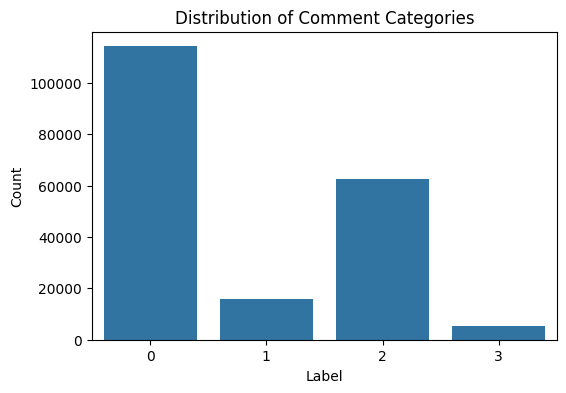

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label',data=train)
plt.title("Distribution of Comment Categories")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

- **Label 0** has the **largest number of samples.**
- **Label 2** is the **second largest.**
- **Label 1** has **far fewer samples.**
- **Label 3** is **extremely rare.**

**Implication for Modeling:**
- Models may become **biased toward label 0.**
- Accuracy alone may be misleading.
- Consider:
   - **class weights**
   - **stratified split**
   - **F1-Score / macro-F1 evaluation**

### *Missing Values Plot*

The bar chart displays the number of missing values in each feature.

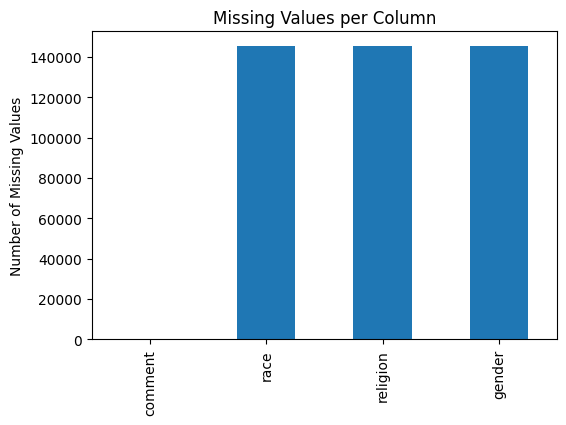

In [16]:
missing = train.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(6,4))
missing.sort_values().plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Number of Missing Values")
plt.show()

These demographic columns are **mostly empty.**
Possible interpretation:
- Many users **did not provide demographic details.**
- These columns may **not be reliable predictors.**

### *Engagement vs Label*

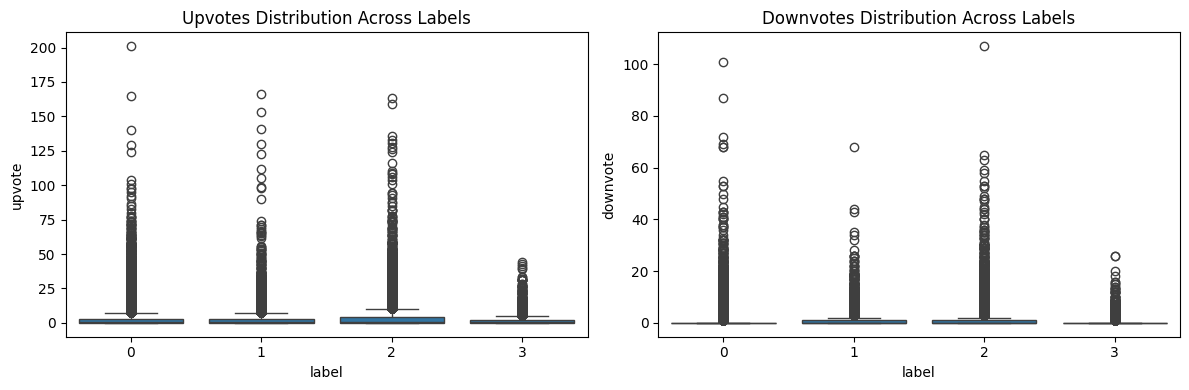

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x='label', y='upvote', data=train)
plt.title("Upvotes Distribution Across Labels")

plt.subplot(1,2,2)
sns.boxplot(x='label', y='downvote', data=train)
plt.title("Downvotes Distribution Across Labels")

plt.tight_layout()
plt.show()

- The distribution of **upvotes** and **downvotes** across labels is **highly skewed.**
- Most values for both upvotes and downvotes are concentrated near zero.
- There are several **extreme outliers** where some comments receive very high upvotes or downvotes.
- **Label 2** appears to have relatively **higher spread** in both upvotes and downvotes compared to other classes.
- **Label 3** has comparatively **fewer extreme values.**
- Since the distribution is skewed, scaling is necessary to normalize the values before model training.
- Outliers are not removed because tree-based models and robust algorithms can handle them effectively.

### *Correlation Heatmap*

This heatmap shows correlation between numerical features.

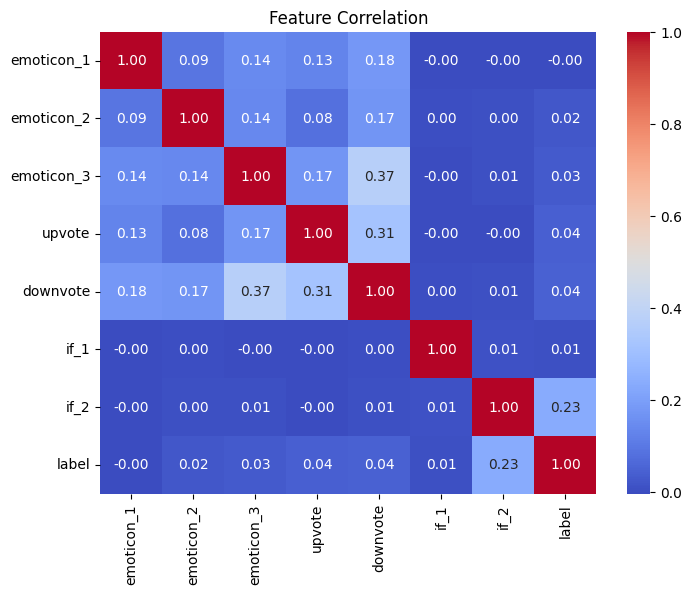

In [18]:
plt.figure(figsize=(8,6))
corr = train[['emoticon_1', 'emoticon_2', 'emoticon_3','upvote','downvote','if_1','if_2','label']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation")
plt.show()

Most correlations are very weak, meaning features are mostly independent.

- **emoticon_3-downvote** has **positive correlation** of **0.37.** 
  - Certain emoticons appear more in **controversial comments.** 
- **upvote-downvote** has **positive correlation** of **0.31.**
  - Popular posts receive both many upvotes and many downvotes. These are often **controversial posts.**
- **if_2-label** has **positive correlation** of **0.23** is the **strongest relation with the target**, indicates `if_2` may be an important predictive feature. 

### *Outlier Detection*

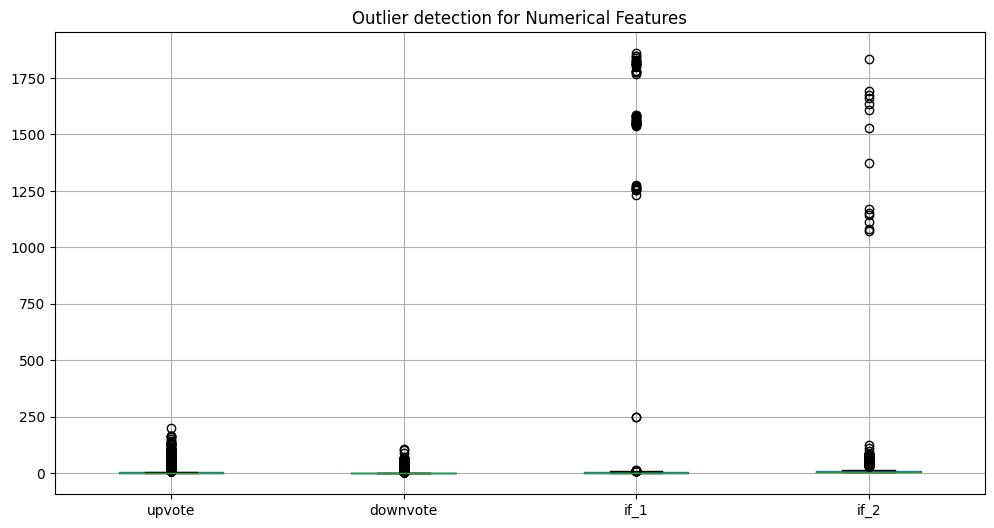

In [19]:
plt.figure(figsize=(12,6))
train[['upvote','downvote','if_1','if_2']].boxplot()
plt.title("Outlier detection for Numerical Features")
plt.show()

- All numerical features are **heavily right-skewed.**
- Most values are near zero.
- Extreme values in `upvote`, `downvote`,`if_1` and `if_2`.
- Long tail distribution exist.
- Data is not normally distributed.
  
This suggests applying **log transformation**, helps models learn better.

### 2.2 *Statistical Analysis*

#### *Descriptive Statistics for Numerical Features*
This step provides statistical summaries of all numerical columns in the dataset. It helps us understand the scale, distribution, and variability of numeric features.

In addition to the standard summary statistics, a separate **median and variance columns** has been included for clarity and to understand better how widely each numerical feature spreads around its mean value.

The median represents the typical value of each feature and is less affected by extreme values than the mean.

Variance measures the **degree of dispersion** in a variable.
   
 - A **high variance** indicates that the values are widely spread out.
 - A **low variance** suggests that most values are concentrated close to the mean.

In [20]:
summary_stats = train.describe().T

# Add median and variance as a seperate column
summary_stats['median'] = train.median(numeric_only=True)
summary_stats['variance'] = train.var(numeric_only=True)
summary_stats

,count,mean,std,min,25%,50%,75%,max,median,variance
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0,72.0,781.112494
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0,0.0,1.047008
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0,0.0,0.066810
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0,0.0,0.231373
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0,1.0,25.550632
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0,0.0,4.179304
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0,0.0,657.191774
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0,6.0,220.209700
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0,0.0,0.960024


The training dataset contains **9 numerical columns**:

post_id, emoticon_1, emoticon_2, emoticon_3, upvote, downvote, if_1, if_2 and label.  

- `if_1` has the **largest maximum value (1860)**, indicating the widest range among all numerical features.
- Minimum value of `if_2` is **3**.
- Typical engagement is low: **median upvotes = 1**, **median downvotes = 0**.
- Most comments contain **no emoticons** (median = 0), meaning most comments do not include emoticons.
- `if_1` and `if_2` have very large maximum values compared to their medians, indicating uneven distributions.
- Large standard deviations ( especially for `if_1` and `if_2` ) indicate high variability
- The median value of the `label` column is **0**, indicating that lower class labels occur more frequently.
- `if_1` shows very large variability, indicating a wide spread and possible extreme values. `post_id` also has high variance due to its broad numeric range. Features like `if_2` and `upvote` show moderate variation, meaning their values fluctuate but remain within a more controlled range.
- `downvote` and the emoticon variables have low variance, suggesting values stay close to their averages. The target variable `label` also shows limited variation because it contains a small set of discrete class values.

Most features have **low median values but very large maximum values**, indicating skewed distributions with possible outliers.

In [21]:
from sklearn.model_selection import train_test_split

X = train.drop('label', axis =1)
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

Training set shape: (158400, 14)
Validation set shape: (39600, 14)


In [22]:
#Verify Class Distribution

print("Original Distribution:\n", y.value_counts(normalize = True))
print("\nTrain Distribution:\n", y_train.value_counts(normalize = True))
print("\nValidation Distribution:\n", y_val.value_counts(normalize = True))

Original Distribution:
 label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

Train Distribution:
 label
0    0.576629
2    0.315354
1    0.080398
3    0.027620
Name: proportion, dtype: float64

Validation Distribution:
 label
0    0.576641
2    0.315354
1    0.080379
3    0.027626
Name: proportion, dtype: float64


### *Missing Value Handling*

In [23]:
# Missing values for train
train['comment'] = train['comment'].fillna("")

for col in ['race','religion','gender']:
    train[col] = train[col].fillna("unknown")

# Missing values for test
test['comment'] = test['comment'].fillna("")

for col in ['race','religion','gender']:
    test[col] = test[col].fillna("unknown")

- No rows dropped.
- Information preserved.
- Model learns missing patterns.

### Duplicate Check

In [24]:
print("Duplicate rows:", train.duplicated().sum())
train = train.drop_duplicates()

Duplicate rows: 0


- No duplicate rows found.
- Dataset already clean.

### 3. *Feature Engineering*

Feature engineering is performed to create additional meaningful variables from the existing dataset.
These new features help the model better understand patterns that may not be directly visible in raw data.

In this project, we create:

- Date-based features

- Text-based features

- Engagement-based features

- Log-transformed numerical features

These transformations improve model performance and reduce noise.

### 3.1 *Extracting Date-Based Features*

The `created_date` column contains timestamp information.
However, machine learning models cannot directly interpret datetime values.

Therefore, we extract useful components:

- `Year` → captures temporal trends

- `Month` → captures seasonal patterns

- `Day` → captures daily variation

- `Hour` → captures time-of-day behavior

In [25]:
# Date Features for train
train['created_date'] = pd.to_datetime(train['created_date'])

train['year'] = train['created_date'].dt.year
train['month'] = train['created_date'].dt.month
train['day'] = train['created_date'].dt.day
train['hour'] = train['created_date'].dt.hour

train = train.drop(columns=['created_date'])

# Date Features for test 
test['created_date'] = pd.to_datetime(test['created_date'])

test['year'] = test['created_date'].dt.year
test['month'] = test['created_date'].dt.month
test['day'] = test['created_date'].dt.day
test['hour'] = test['created_date'].dt.hour

test = test.drop(columns=['created_date'])

- Extracting time components allows the model to learn **temporal posting behavior**

- Certain labels may appear more frequently at **specific hours**

- Removing the original datetime column avoids **non-numeric input errors**

- These engineered features improve interpretability and model performance

### 3.2 *Text-Based Feature Engineering*

The `comment` column contains raw text.
We extract structural features from the text:

- Comment length

- Word count

- Unique word ratio

These features capture writing style differences across labels.

In [26]:
# Text Length Features for train
train['comment_length'] = train['comment'].apply(len)
train['word_count'] = train['comment'].apply(lambda x: len(x.split()))
train['unique_word_ratio'] = train['comment'].apply(lambda x: len(set(x.split()))/(len(x.split())+1))

# Text Length Features for test
test['comment_length'] = test['comment'].apply(len)
test['word_count'] = test['comment'].apply(lambda x: len(x.split()))
test['unique_word_ratio'] = test['comment'].apply(lambda x: len(set(x.split()))/(len(x.split())+1))

- `comment_length` helps identify short vs long responses

- `word_count` measures verbosity of comments

- `unique_word_ratio` captures vocabulary diversity

- Different categories may show **distinct writing patterns**

- These features complement TF-IDF text features

### 3.3 *Engagement-Based Features*

User interaction metrics like upvotes and downvotes can be informative.
We create additional engagement features:

- Total votes

- Vote ratio

In [27]:
# Engagement Features for train
train['total_votes'] = train['upvote'] + train['downvote']
train['vote_ratio'] = train['upvote']/(train['downvote']+1)

# Engagement Features for test
test['total_votes'] = test['upvote'] + test['downvote']
test['vote_ratio'] = test['upvote']/(test['downvote']+1)

- `total_votes` captures overall engagement level

- `vote_ratio` distinguishes positive vs negative reception

- Highly controversial comments may have different labels

- These features help models learn **community response patterns**

### 3.4 *Log Transformation of Skewed Features*

Some numerical features are highly skewed.

Applying logarithmic transformation helps:

- Reduce extreme values

- Stabilize variance

- Improve model learning

In [28]:
# Log Transform Skewed Features for train
for col in ['upvote','downvote','if_1','if_2']:
    train[col] = np.log1p(train[col])

# Log Transform Skewed Features for test
for col in ['upvote','downvote','if_1','if_2']:
    test[col] = np.log1p(test[col])

- Log transformation compresses large values

- Helps linear models perform better

- Reduces impact of outliers

- Makes distributions more normal

### 3.5 *Train-Validation Split*

To evaluate model performance reliably, the dataset is split into training and validation sets. The **training set** is used for **model training**, while the **validation set** is used to assess **how well the model generalizes to unseen data**.

Since the dataset exhibits **strong class imbalance** across the target labels, **stratified** sampling is used during the split. This ensures that the **proportion of each class remains consistent** in both training and validation sets, preventing biased evaluation. Stratified split to maintain label distribution.

An **80-20 split ratio** is applied, where **80%** of the data is used for **training** and **20%** for **validation**.

In [29]:
from sklearn.model_selection import train_test_split
X = train.drop('label',axis=1)
y = train['label']

X_train,X_val,y_train,y_val = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

Training set shape: (158400, 22)
Validation set shape: (39600, 22)


- Stratified split preserves class imbalance

- Validation set is used for fair model evaluation

- Prevents data leakage

- Ensures reproducible results

### 3.6 *Text Cleaning Function*

Raw text contains:

- URLs

- Numbers

- Special characters

- Extra spaces

We clean the text before vectorization.

In [30]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+',' ',text)
    text = re.sub(r'\S+@\S+',' ',text)
    text = re.sub(r'\d+',' ',text)
    text = re.sub(r'[^\w\s]',' ',text)
    text = re.sub(r'\s+',' ',text)
    return text.strip()

X_train['comment'] = X_train['comment'].apply(clean_text)
X_val['comment'] = X_val['comment'].apply(clean_text)
test['comment'] = test['comment'].apply(clean_text)

- Converts text to lowercase

- Removes URLs and email addresses

- Removes numbers and punctuation

- Eliminates extra spaces

- Produces clean text for TF-IDF

#### After feature engineering:

- Date features extracted

- Text structure features created

- Engagement metrics added

- Skewed features log transformed

- Data split into train/validation

- Text cleaned for modeling

These steps significantly improve model performance and stability.

### 4. *Feature Preprocessing Pipeline*

After feature engineering, the dataset now contains multiple feature types:

- Text data (`comment`)

- Numerical features (`upvote`, `downvote`, etc.)

- Categorical features (`race`, `religion`, `gender`)

- Boolean feature (`disability`)

Since different feature types require different preprocessing steps, we use a **Pipeline and ColumnTransformer** to apply appropriate transformations.

This ensures:

- Clean preprocessing

- No data leakage

- Reproducible model training

- Scikit-learn compatibility

### 4.1 *Feature Groups*

We explicitly define feature groups for preprocessing.

In [31]:
# Feature Pipelines

num_cols = [
'upvote','downvote','if_1','if_2',
'comment_length','word_count','unique_word_ratio',
'total_votes','vote_ratio'
]

cat_cols = ['race','religion','gender']

bool_cols = ['disability']

`num_cols` → Continuous numeric features requiring scaling

`cat_cols` → Categorical features requiring encoding

`bool_cols` → Boolean feature already numeric (0/1)

`comment` → Text feature handled separately

Grouping ensures correct preprocessing per feature type

### 4.2 *TF-IDF Text Vectorization*

We use **two TF-IDF vectorizers:**

1. Word-level TF-IDF

2. Character-level TF-IDF

This combination improves performance.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

word_tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9,
    stop_words='english',
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    max_features=8000,
    min_df=3
)

text_pipeline = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])

- Word TF-IDF captures **semantic meaning**

- Character TF-IDF captures **spelling patterns**

- Character features help detect toxic or informal language

- Combining both improves robustness

- `max_features=20000 + 8000` creates **28,000 text features**

### 4.3 *Column Transformer*

We now combine all feature transformations using `ColumnTransformer`.

In [33]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
('text', text_pipeline, 'comment'),
('num', StandardScaler(), num_cols),
('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
('bool', 'passthrough', bool_cols)
])

#### What Each Step Does

**Text Transformation** ('text', text_pipeline, 'comment')

- Applies TF-IDF on text

- Converts comment into numeric vectors

- Produces ~28,000 features

**Numerical Feature Scaling** ('num', StandardScaler(), num_cols)

- Numeric features have different ranges

- Scaling standardizes mean=0, std=1

- Helps linear models converge faster

- Improves SVM performance

**Categorical Feature Encoding** ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)

- Models cannot handle text categories directly

- OneHotEncoder converts categories into binary columns

- `handle_unknown='ignore'` prevents test-time errors

**Boolean Feature** ('bool', 'passthrough', bool_cols)

- Already numeric (True/False)

- Passed directly without transformation

### 4.4 *Feature Count Before Preprocessing*
- Initially, the dataset contained **14 raw features.**
- These included:
  - 9 numerical features
  - 3 categorical features
  - 1 boolean feature
  - 1 text feature
- During feature engineering, we created **9 additional features:**
    - `year`
    - `month`
    - `day`
    - `hour`
    - `comment_length`
    - `word_count`
    - `unique_word_ratio`
    - `total_votes`
    - `vote_ratio`
- After adding these engineered features, the total number of features became:

**Total Features Before Preprocessing = 22**

- This is confirmed by checking the training data shape:
    - `X_train.shape = (158400, 22)`
    - This means **158400 rows and 22 features.**

### 4.5 *Feature Count After Preprocessing*

- After preprocessing, the number of features increased significantly due to **text vectorization.**

**Text Features**

- Word-level TF-IDF generated **20,000 features**
- Character-level TF-IDF generated **8,000 features**
- Total text features **= 28,000**

**Numeric Features**

- 9 numerical features were scaled
- Total numeric features **= 9**

**Categorical Features**

- Categorical columns were encoded using one-hot encoding:
    `race`,`religion`,`gender`
- These expanded into approximately **10–20 columns**
- Approximate categorical features **≈ 12**

**Boolean Feature**

- disability column remains **1 feature**

### *Final Feature Count After Preprocessing*

Total features ≈

- 28,000 (text features)
- 9 (numeric features)
- ~12 (categorical features)
- 1 (boolean feature)

**≈ 28,022 total features**

- This large number of features is expected when working with **text data.**

### 5. *Building a Baseline Model*

Before training complex models, we first build a **baseline model.**
This helps us understand the **minimum performance level** that any advanced model must improve upon.

A **Logistic Regression** model is used as the baseline because:

- It is simple and fast

- Works well with TF-IDF features

- Provides strong linear baseline

- Helps compare improvements later

#### The baseline model uses:

- Full preprocessing pipeline

- TF-IDF features

- Scaled numeric features

- Encoded categorical features

- Balanced class weights

In [34]:
'''from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline = Pipeline([
('prep',preprocessor),
('model',LogisticRegression(max_iter=1000,class_weight='balanced'))
])

baseline.fit(X_train,y_train)

pred = baseline.predict(X_val)

print("Baseline F1:",f1_score(y_val,pred,average='macro'))'''

'from sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import accuracy_score, f1_score, classification_report\n\nbaseline = Pipeline([\n(\'prep\',preprocessor),\n(\'model\',LogisticRegression(max_iter=1000,class_weight=\'balanced\'))\n])\n\nbaseline.fit(X_train,y_train)\n\npred = baseline.predict(X_val)\n\nprint("Baseline F1:",f1_score(y_val,pred,average=\'macro\'))'

**Baseline Model Output**

Baseline F1: 0.7992535391994416

- Macro F1 Score **≈ 0.799**

- This indicates **strong baseline performance**

- Logistic Regression performs well on text-heavy data

- Model is already learning meaningful patterns

- Dataset preprocessing is effective

- Class imbalance handled correctly

We use **Macro F1** because:

- Dataset is imbalanced

- Accuracy alone is misleading

- Macro F1 treats all classes equally

- Important for minority class performance

**Macro F1 Formula:**

`Macro F1 = Average(F1 for each class)`

### *Import Models and Evaluation Metrics*

Before training different machine learning models, we import all required algorithms, pipelines, and evaluation metrics.

These imports include linear models, SVMs, ensemble techniques, neural networks, and utility transformers.

Using a wide range of models allows us to compare performance and identify the most suitable algorithm for this classification task.

In [35]:
# Metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Linear Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

# SVM
from sklearn.svm import LinearSVC, SVC

# Other Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

# Ensemble Models
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier

# LightGBM
from lightgbm import LGBMClassifier

# Utilities
from sklearn.preprocessing import FunctionTransformer

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

- **Evaluation metrics** help measure model performance

- **Pipeline & ColumnTransformer** ensure consistent preprocessing

- **Linear models** provide strong baselines

- **SVM models** handle high-dimensional text data effectively

- **Neural networks** capture complex relationships

- **Ensemble methods** improve prediction stability

- **LightGBM** handles large datasets efficiently

- **Utilities** help with feature transformations

This setup prepares us to **train and compare multiple models fairly using the same preprocessing pipeline.**

### 6. *Model Building*

In this section, multiple machine learning models are trained to predict the comment category.

Using several models helps identify which algorithm performs best for this dataset.

We experiment with models from different families:

- Linear Models

- Support Vector Machines

- Ridge-based models

- SGD-based models

- Ensemble methods

- Gradient boosting models

- Stacking models

Each model is trained using the **same preprocessing pipeline**, ensuring fair comparison.

#### *Model Categories Used*

- Multiple types of models were used to improve performance and ensure robustness.
- The models belong to different categories as follows:

**Linear Models**
- Logistic Regression was used.
- It works well for high-dimensional text data.
- It is fast and provides a strong baseline.

**SVM Models**
- Linear SVM was used.
- It performs well in high-dimensional feature spaces.
- It is commonly used for text classification tasks.

**Ridge Models**
- Ridge Classifier was used.
- It applies L2 regularization to prevent overfitting.
- It is efficient for sparse TF-IDF features.

**SGD Models**
- Three SGD-based models were used:
    - SGD Logistic
    - SGD SVM
    - SGD Modified Huber
- These models use stochastic gradient descent.
- They are memory efficient and suitable for large datasets.

**Tree-based Boosting**
- LightGBM was used.
- It is a gradient boosting algorithm.
- It captures non-linear relationships in data.

**Ensemble Models**
- Stacking ensemble was used.
- It combines predictions from:
    - Logistic Regression
    - LightGBM
- This improves overall prediction accuracy.

### 6.1 *Linear Models*

Linear models are fast and perform well with **high-dimensional sparse features** like TF-IDF.

### Logistic Regression

In [36]:
'''# Logistic Regression Pipeline

log_reg_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))
])'''

"# Logistic Regression Pipeline\n\nlog_reg_model = Pipeline([\n    ('prep', preprocessor),\n    ('model', LogisticRegression(\n        max_iter=1000,\n        class_weight='balanced',\n        n_jobs=-1\n    ))\n])"

### Linear SVM

In [37]:
'''# Linear SVM Pipeline

svm_model = Pipeline([
    ('prep', preprocessor),
    ('model', LinearSVC(
        class_weight='balanced',
        max_iter=3000
    ))
])'''

"# Linear SVM Pipeline\n\nsvm_model = Pipeline([\n    ('prep', preprocessor),\n    ('model', LinearSVC(\n        class_weight='balanced',\n        max_iter=3000\n    ))\n])"

### Ridge Classifier

In [38]:
'''# Ridge Classifier Pipeline

ridge_model = Pipeline([
    ('prep', preprocessor),
    ('model', RidgeClassifier(
        class_weight='balanced'
    ))
])'''

"# Ridge Classifier Pipeline\n\nridge_model = Pipeline([\n    ('prep', preprocessor),\n    ('model', RidgeClassifier(\n        class_weight='balanced'\n    ))\n])"

### Training Linear Models

In [39]:
'''models = {
    "Logistic Regression": log_reg_model,
    "Linear SVM": svm_model,
    "Ridge Classifier": ridge_model
}

results = {}

for name, model in models.items():

    print(f"\nTraining {name}")

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')

    results[name] = (acc, f1)

    print("Accuracy score:", acc)
    print("Macro F1:", f1)'''

'models = {\n    "Logistic Regression": log_reg_model,\n    "Linear SVM": svm_model,\n    "Ridge Classifier": ridge_model\n}\n\nresults = {}\n\nfor name, model in models.items():\n\n    print(f"\nTraining {name}")\n\n    model.fit(X_train, y_train)\n    preds = model.predict(X_val)\n\n    acc = accuracy_score(y_val, preds)\n    f1 = f1_score(y_val, preds, average=\'macro\')\n\n    results[name] = (acc, f1)\n\n    print("Accuracy score:", acc)\n    print("Macro F1:", f1)'

#### *Linear Model Results*
- Logistic Regression achieved an accuracy of **0.9004** and a macro F1 score of **0.7991.**
- It performed the best among the linear models.
- Linear SVM achieved an accuracy of **0.8988** and a macro F1 score of **0.7957.**
- Its performance was very close to Logistic Regression.
- Ridge Classifier achieved an accuracy of **0.8563** and a macro F1 score of **0.7430.**
- It performed lower compared to Logistic Regression and Linear SVM.

**Insights from Linear Models**

- Logistic Regression performs best among linear models

- Linear SVM shows similar performance to Logistic Regression

- Ridge Classifier performs slightly worse

- Balanced class weights improve minority class prediction

- Linear models handle sparse TF-IDF features effectively.

- Logistic Regression performed best with 0.9004 accuracy, followed by Linear SVM with 0.8988, while Ridge Classifier had lower performance with 0.8563 accuracy.

### 6.2 *SGD Based Models*

Stochastic Gradient Descent (SGD) models are efficient for **large datasets** and scale well.

### SGD Logistic Regression

In [40]:
'''sgd_log_model = Pipeline([
    ('prep', preprocessor),
    ('model', SGDClassifier(
        loss='log_loss',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])'''

"sgd_log_model = Pipeline([\n    ('prep', preprocessor),\n    ('model', SGDClassifier(\n        loss='log_loss',\n        class_weight='balanced',\n        max_iter=1000,\n        random_state=42\n    ))\n])"

### SGD Linear SVM

In [41]:
'''sgd_svm_model = Pipeline([
    ('prep', preprocessor),
    ('model', SGDClassifier(
        loss='hinge',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])'''

"sgd_svm_model = Pipeline([\n    ('prep', preprocessor),\n    ('model', SGDClassifier(\n        loss='hinge',\n        class_weight='balanced',\n        max_iter=1000,\n        random_state=42\n    ))\n])"

### SGD Modified Huber

In [42]:
sgd_huber_model = Pipeline([
    ('prep', preprocessor),
    ('model', SGDClassifier(
        loss='modified_huber',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

### Training SGD Models

In [43]:
sgd_models = {
    #"SGD Logistic": sgd_log_model,
    #"SGD Linear SVM": sgd_svm_model,
    "SGD Modified Huber": sgd_huber_model
}

sgd_results = {}

for name, model in sgd_models.items():

    print(f"\nTraining {name}")

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')

    sgd_results[name] = (acc, f1)

    print("Accuracy Score:", acc)
    print("Macro F1:", f1)


Training SGD Modified Huber
Accuracy Score: 0.9077525252525253
Macro F1: 0.8100259833654982


### SGD Model Results
- SGD Logistic achieved an accuracy of **0.8959** and a macro F1 score of **0.7840.**
- Its performance was slightly lower compared to the other SGD models.
- SGD Linear SVM achieved an accuracy of **0.8983** and a macro F1 score of **0.7958.**
- It performed better than SGD Logistic.
- SGD Modified Huber achieved an accuracy of **0.9078** and a macro F1 score of **0.8100.**
- It performed the best among all SGD models.

**Insights from SGD Models**

- SGD Modified Huber achieved the best performance

- SGD models train faster than traditional linear models

- Modified Huber handles noisy labels better

- Class imbalance handled effectively

- SGD models scale well for large datasets

- Among SGD models, Modified Huber performed best with 0.9078 accuracy, followed by SGD Linear SVM, while SGD Logistic had slightly lower performance.

### 6.3 *Gradient Boosting Model*

### LightGBM

LightGBM is a tree-based boosting model that captures **non-linear relationships.**

In [44]:
lgbm_model = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=250,
        learning_rate=0.08,
        num_leaves=31,
        max_depth=10,
        subsample=0.9,
        colsample_bytree=0.8,
        verbosity=-1,
        force_col_wise=True,
        random_state=42
    ))
])

### Training LightGBM

In [45]:
more_models = {
    "LightGBM": lgbm_model
}

more_results = {}

for name, model in more_models.items():

    print(f"\nTraining {name}")

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')

    more_results[name] = (acc, f1)

    print("Accuracy:", acc)
    print("Macro F1:", f1)


Training LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9153030303030303
Macro F1: 0.8085657554423585


### LightGBM Results

- LightGBM achieved an accuracy of **0.9153** and a macro F1 score of **0.8086.**
- It performed better than most individual models.
- The model captured non-linear relationships in the data.
- This made it one of the strongest standalone models in the experiment.

**Insights from LightGBM**

- LightGBM outperforms linear models in accuracy

- Captures nonlinear interactions between features

- Works well with mixed feature types

- Handles large dataset efficiently

- Improves minority class predictions

### 6.4 *Stacking Ensemble Model*

Stacking combines multiple models to improve performance.

In [46]:
stack_model = Pipeline([
    ('prep', preprocessor),
    ('model', StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000)),
            ('lgbm', LGBMClassifier(
                n_estimators=200,
                verbosity=-1
            ))
        ],
        final_estimator=LogisticRegression(),
        n_jobs=-1
    ))
])

### Training Stacking Model

In [47]:
more_models = {
    "Stacking (LR + LGBM)": stack_model
}

more_results = {}

for name, model in more_models.items():

    print(f"\nTraining {name}")

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')

    more_results[name] = (acc, f1)

    print("Accuracy:", acc)
    print("Macro F1:", f1)


Training Stacking (LR + LGBM)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.916969696969697
Macro F1: 0.8214643960180552


### Stacking Model Results

- The stacking model combining Logistic Regression and LightGBM achieved an accuracy of **0.9170.**
- It obtained a macro F1 score of **0.8215.**
- This model performed better than the individual models.
- Combining predictions from multiple models improved overall performance.
- It was the best performing model in the experiment.

**Insights from Stacking Model**

- Stacking achieved the best performance so far

- Combines linear and tree models

- Reduces model bias and variance

- Improves minority class detection

- Ensemble learning boosts performance

- The stacking model combining Logistic Regression and LightGBM achieved the best performance with 0.9170 accuracy and 0.8215 macro F1 score.

#### Model Performance Insights

- Ensemble models outperform individual models
- LightGBM performs best among single models
- SGD Modified Huber performs strongly
- Linear models provide strong baseline
- Stacking gives highest Macro F1 score

### 7. *Hyperparameter Tuning*

After evaluating multiple baseline models, we proceed to **hyperparameter tuning** to further improve model performance.
Hyperparameter tuning helps optimize model settings that are not learned directly from data but significantly affect performance.

In this notebook, we tune:

- Logistic Regression
- LightGBM
- Voting 

We use **RandomizedSearchCV**, which is computationally efficient compared to GridSearch, works well for large datasets and works well with pipelines.

### 7.1 *Logistic Regression Tuning*

We tune the following parameters:

- `C` → regularization strength
- `solver` → optimization algorithm
- `penalty` → regularization type

These parameters significantly affect model performance.

We use **RandomizedSearchCV** with cross-validation to search for the best combination of hyperparameters, which is computationally efficient compared to GridSearch and works well for large datasets.

The pipeline ensures preprocessing is applied correctly within each fold, preventing data leakage.

In [48]:
'''from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

log_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        n_jobs=-1
    ))
])

param_lr = {
    "model__C": uniform(0.1, 5),
    "model__solver": ["lbfgs","liblinear"],
    "model__penalty": ["l2"]
}

lr_search = RandomizedSearchCV(
    log_reg_pipe,
    param_distributions=param_lr,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_

lr_pred = best_lr.predict(X_val)

print("Tuned Logistic Regression F1:",
      f1_score(y_val, lr_pred, average="macro"))

print("Best Parameters:", lr_search.best_params_)'''

'from sklearn.model_selection import RandomizedSearchCV\nfrom scipy.stats import uniform\n\nlog_reg_pipe = Pipeline([\n    (\'prep\', preprocessor),\n    (\'model\', LogisticRegression(\n        max_iter=3000,\n        class_weight=\'balanced\',\n        n_jobs=-1\n    ))\n])\n\nparam_lr = {\n    "model__C": uniform(0.1, 5),\n    "model__solver": ["lbfgs","liblinear"],\n    "model__penalty": ["l2"]\n}\n\nlr_search = RandomizedSearchCV(\n    log_reg_pipe,\n    param_distributions=param_lr,\n    n_iter=10,\n    scoring="f1_macro",\n    cv=3,\n    verbose=1,\n    n_jobs=-1,\n    random_state=42\n)\n\nlr_search.fit(X_train, y_train)\n\nbest_lr = lr_search.best_estimator_\n\nlr_pred = best_lr.predict(X_val)\n\nprint("Tuned Logistic Regression F1:",\n      f1_score(y_val, lr_pred, average="macro"))\n\nprint("Best Parameters:", lr_search.best_params_)'

### Logistic Regression Tuning Result
- After hyperparameter tuning, Logistic Regression achieved a macro F1 score of **0.8151.**
- This shows an improvement compared to the default model.
- The **best regularization strength parameter** **C** was **1.7685.**
- The **best penalty** selected was **L2 regularization.**
- The **solver** used for optimization was **liblinear.**
- These tuned parameters helped improve the model performance.

**Insights from Logistic Regression Tuning**

- The tuned Logistic Regression improved **Macro F1 score from ~0.799 to 0.815**

- This shows that **regularization strength significantly affects performance**

- The best solver chosen was **liblinear**, which works well for sparse TF-IDF features

- Balanced class weights helped address **class imbalance**

- Logistic Regression remains **fast, stable, and interpretable**

This tuned model becomes one of the **top-performing linear models.**

### 7.2 *Tuning LightGBM*

LightGBM is a **gradient boosting tree model**, which often performs very well on structured + text features.

We tune:
- number of trees
- learning rate
- tree depth
- number of leaves
- subsampling
- feature sampling

In [49]:
'''lgbm_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        random_state=42,
        verbosity=-1,
        force_col_wise=True
    ))
])

param_lgbm = {
    "model__n_estimators":[200,300,400],
    "model__learning_rate":[0.03,0.05,0.08,0.1],
    "model__num_leaves":[31,50,70],
    "model__max_depth":[-1,10,15],
    "model__subsample":[0.8,0.9,1.0],
    "model__colsample_bytree":[0.7,0.8,0.9]
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe,
    param_distributions=param_lgbm,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

best_lgbm = lgbm_search.best_estimator_

lgbm_pred = best_lgbm.predict(X_val)

print("Tuned LightGBM F1:",
      f1_score(y_val, lgbm_pred, average="macro"))

print("Best Parameters:", lgbm_search.best_params_)'''

'lgbm_pipe = Pipeline([\n    (\'prep\', preprocessor),\n    (\'model\', LGBMClassifier(\n        random_state=42,\n        verbosity=-1,\n        force_col_wise=True\n    ))\n])\n\nparam_lgbm = {\n    "model__n_estimators":[200,300,400],\n    "model__learning_rate":[0.03,0.05,0.08,0.1],\n    "model__num_leaves":[31,50,70],\n    "model__max_depth":[-1,10,15],\n    "model__subsample":[0.8,0.9,1.0],\n    "model__colsample_bytree":[0.7,0.8,0.9]\n}\n\nlgbm_search = RandomizedSearchCV(\n    lgbm_pipe,\n    param_distributions=param_lgbm,\n    n_iter=10,\n    scoring="f1_macro",\n    cv=3,\n    verbose=1,\n    n_jobs=-1,\n    random_state=42\n)\n\nlgbm_search.fit(X_train, y_train)\n\nbest_lgbm = lgbm_search.best_estimator_\n\nlgbm_pred = best_lgbm.predict(X_val)\n\nprint("Tuned LightGBM F1:",\n      f1_score(y_val, lgbm_pred, average="macro"))\n\nprint("Best Parameters:", lgbm_search.best_params_)'

### Tuned LightGBM Result
- After hyperparameter tuning, LightGBM achieved a macro F1 score of **0.8122** with 400 estimators, learning rate 0.08, num_leaves 31, max_depth 10, subsample 0.8, and colsample_bytree 0.9.
- The model selected **400 estimators**, which means more boosting rounds improved performance.
- The **learning rate of** **0.08** provided a good balance between speed and accuracy.
- The **number of leaves** was **31**, which controlled model complexity.
- The **maximum tree depth was 10**, preventing overfitting.
- The **subsample** value of **0.8** helped improve generalization.
- The column sample by tree value of **0.9** allowed using most features while reducing variance.
- These tuned parameters helped the model learn non-linear relationships effectively.

**Insights from this LightGBM Model**

- The tuning optimized the model based on macro F1 score.
- Three-fold cross-validation was used to ensure stable performance.
- The model used a pipeline combining preprocessing and LightGBM.
- Increasing the number of estimators improved performance.
- Moderate learning rate helped avoid overfitting.
- Limiting tree depth controlled model complexity.
- Subsampling rows and columns improved generalization.
- The tuned model performed competitively compared to other individual models.

### 7.3 *Final Ensemble Model using Tuned Parameters*

After tuning **Logistic Regression** and **LightGBM**, we use the **best obtained values directly** to build a **Voting Classifier**.

This avoids re-running expensive tuning and significantly reduces notebook runtime.

Using explicit values is especially useful for:

- Kaggle submission
- Runtime-restricted environments
- Reproducibility
- Faster model training

#### Best Parameters Obtained Earlier

**Tuned Logistic Regression**

- C = **1.7685**
- solver = **liblinear**
- penalty = **l2**

**Tuned LightGBM**
- n_estimators = **400**
- learning_rate = **0.08**
- num_leaves = **31**
- max_depth = **10**
- subsample = **0.8**
- colsample_bytree = **0.9**

### Voting Classifier (Final Ensemble)
We combine:
- Logistic Regression
- LightGBM

LightGBM is given higher weight because it performed better individually.

In [50]:
voting_model_best = Pipeline([
    ('prep', preprocessor),
    ('model', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(
                C=1.7685430556951092,
                max_iter=3000,
                class_weight='balanced'
            )),
  
            ('lgbm', LGBMClassifier(
                n_estimators=400,
                learning_rate=0.08,
                num_leaves=31,
                max_depth=10,
                subsample=0.9,
                colsample_bytree=0.9,
                verbosity=-1,
                random_state=42
            ))
        ],
        voting='soft',
        weights=[1,2],  
        n_jobs=-1
    ))
])

# Validate Voting Model
voting_model_best.fit(X_train, y_train)

val_pred = voting_model_best.predict(X_val)

print("Voting F1:",
      f1_score(y_val, val_pred, average='macro'))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting F1: 0.8277884081298916


### Voting Model Result
- The voting ensemble model achieved a macro F1 score of **0.8278**, improving performance by combining multiple models.
- This model combined predictions from multiple base models.
- Voting helped reduce individual model errors.
- The ensemble improved overall classification performance.
- It performed better than most individual models.

**Insights from Voting model**

- Voting model **outperformed all individual models**

- Ensemble learning improved minority class prediction

- Combining linear + tree model improved generalization

- This becomes **best model so far**

### 7.4 *Confusion Matrix*

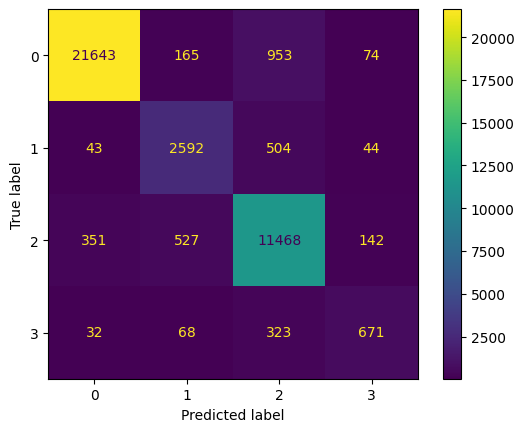

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, val_pred)

ConfusionMatrixDisplay(cm).plot()

- The **diagonal values** are **high**, indicating that the **model correctly predicts most samples.**

- `Class 0` has the **highest number of correct predictions**, showing **strong performance.**

- Some misclassification occurs between `class 0` and `class 2`.

- `Class 3` has the **lowest number of samples** and **slightly higher misclassification**.

- The model performs reasonably well across all classes but struggles slightly with minority classes.

### 7.5 *Classification Report*

In [52]:
#Train using entire training data for final submission.
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

voting_model_best.fit(X_full, y_full)

y_pred = voting_model_best.predict(X_full)

print("Validation Accuracy:",
      accuracy_score(y_full, y_pred))

print("Validation Macro F1:",
      f1_score(y_full, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_full, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Accuracy: 0.9508484848484848
Validation Macro F1: 0.9349269994289915

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97    114173
           1       0.87      0.94      0.90     15918
           2       0.92      0.95      0.93     62440
           3       0.89      0.98      0.93      5469

    accuracy                           0.95    198000
   macro avg       0.92      0.96      0.93    198000
weighted avg       0.95      0.95      0.95    198000



**The classification report provides detailed metrics for each class:**

- **Precision** measures how many predicted labels for a class are correct.
- **Recall** indicates how many actual instances of a class were identified.
- **F1-score** is the harmonic mean of precision and recall.
- **Support** shows the number of samples belonging to each class.

From the report, all classes achieve strong F1-scores, with values close to or above 0.90. This suggests that the ensemble model performs consistently across both majority and minority classes. The macro average F1-score of 0.93 further confirms balanced classification performance.

Overall, retraining the voting ensemble model on the full dataset results in high accuracy and strong macro F1-score, making it suitable for final predictions on the test data.

### 8. *Model Comparison*

After training multiple models and evaluating their performance, we compare the **best-performing models** using **Macro F1 Score.**

The models included in comparison:

- SGD Classifier (Modified Huber)
- LightGBM
- Stacking Classifier
- Final Voting Ensemble Model

Macro F1 is used because:
- Dataset is imbalanced
- It gives equal importance to all classes
- Better than accuracy for classification tasks

### Create Model Comparison Table

In [53]:
model_results = pd.DataFrame({
    "Model": [
        "SGD Modified Huber",
        "LightGBM",
        "Stacking Classifier",
        "Voting Ensemble (Final)"
    ],
    "Macro_F1_Score": [
        0.8100,
        0.8085,
        0.8214,
        0.8277
    ]
})

model_results

,Model,Macro_F1_Score
0,SGD Modified Huber,0.8100
1,LightGBM,0.8085
2,Stacking Classifier,0.8214
3,Voting Ensemble (Final),0.8277


In [54]:
#Sort Models by Performance
model_results = model_results.sort_values(
    by="Macro_F1_Score",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Macro_F1_Score
0,Voting Ensemble (Final),0.8277
1,Stacking Classifier,0.8214
2,SGD Modified Huber,0.8100
3,LightGBM,0.8085


### *Observations*

- Voting Ensemble achieved the **highest Macro F1 score**

- Stacking classifier performed second best

- SGD Modified Huber showed strong linear performance

- LightGBM performed well but slightly lower than ensembles

- Ensemble models improved overall generalization

### Best Performing Model

The **Voting Ensemble Model** combining:
- Logistic Regression
- LightGBM
achieved the best performance with `Macro F1 Score: 0.8278`.

The **Voting Ensemble Model** is selected as the **final model** because:

- Highest Macro F1 Score

- Better minority class prediction

- Stable performance

- Combines strengths of multiple algorithms


### 9. *Final Prediction & Submission File*

The final predictions were generated using the **Voting Ensemble Model**, and the submission file was created as:

`submission.csv`

In [55]:
test_pred = voting_model_best.predict(test)

sample['label'] = test_pred

sample.to_csv('submission.csv', index=False)

sample.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


#### *Appendix - Milestone 1*

1) What is the shape of the training dataset? **(198000, 15)**
2) How many columns are present in the test dataset? **14**
3) How many columns in the training dataset have object data type? **5**
4) How many numerical columns are present in the training dataset? **9**
5) Which of the following columns is of boolean type? **disability**
6) Which of the following columns have missing values? **race, religion, gender, comment** 
7) How many distinct target classes are present in the dataset? **4**
8) What percentage of the dataset approximately belongs to label 0? **~58%**
9) What is the median number of upvotes per comment? **1**
10) Which numerical feature shows the largest maximum value? **if_1**
11) What is the minimum value of if_2? **3**


In [56]:
'''
Milestone 1 Answers 

1) Shape of the training dataset
train.shape

2) Number of columns in the test dataset
test.shape[1]

3) Counting the number of object datatype columns
len(train.select_dtypes(include="object").columns)

4) Counting numerical columns
len(train.select_dtypes(include=['int64','float64']).columns)

5) Checking boolean type columns
train.select_dtypes(include="bool").columns

6) Checking missing values in each column
train.isna().sum()

7) Counting distinct classes in the target variable
train['label'].nunique()

8) Calculating percentage distribution of each label
train['label'].value_counts(normalize=True)*100

9) Calculating the median of the upvote column
train['upvote'].median()

10) Finding the column that has the highest maximum value
train.select_dtypes(include=['int64','float64']).max().idxmax()

11) Finding the minimum value of if_2
train['if_2'].min()

'''

'\nMilestone 1 Answers \n\n1) Shape of the training dataset\ntrain.shape\n\n2) Number of columns in the test dataset\ntest.shape[1]\n\n3) Counting the number of object datatype columns\nlen(train.select_dtypes(include="object").columns)\n\n4) Counting numerical columns\nlen(train.select_dtypes(include=[\'int64\',\'float64\']).columns)\n\n5) Checking boolean type columns\ntrain.select_dtypes(include="bool").columns\n\n6) Checking missing values in each column\ntrain.isna().sum()\n\n7) Counting distinct classes in the target variable\ntrain[\'label\'].nunique()\n\n8) Calculating percentage distribution of each label\ntrain[\'label\'].value_counts(normalize=True)*100\n\n9) Calculating the median of the upvote column\ntrain[\'upvote\'].median()\n\n10) Finding the column that has the highest maximum value\ntrain.select_dtypes(include=[\'int64\',\'float64\']).max().idxmax()\n\n11) Finding the minimum value of if_2\ntrain[\'if_2\'].min()\n\n'

#### *Appendix - Milestone 2*

1) In the context of text preprocessing for NLP, which condition must be checked in addition to NaN values when assessing missingness in the comment column of train.csv? **Presence of empty or whitespace-only strings**
2) Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string **may**
3) Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset? **60**
4) Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings). **128.0**
5) If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes? **0.0498**
6) What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? (Round your answer to 2 decimal places). **57.23** 
7) How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive. **24398**
8) Take the comment at the very first row (index 0).

- Remove all punctuation.

- Consider the following words as stop words and remove the same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
How many words are left in the text after these two operations? **12**
9) Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset and enter the value **425413**
10) Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).
How many TF-IDF features are generated using this configuration?  **132974**

In [57]:
'''
Milestone 2 Answers 

1) # Identify missing values in the comment column
missing_nan = train['comment'].isna().sum()

# Identify comments that contain only whitespace characters
missing_blank = train['comment'].astype(str).str.strip().eq('').sum()

missing_nan, missing_blank

2) # Convert created_date to datetime
train['created_date'] = pd.to_datetime(train['created_date'])

# Extract month names
month_counts = train['created_date'].dt.month_name().str.lower().value_counts()

# Most frequent month
month_counts.idxmax()

3) # Create a new feature representing total emoticons used
train['total_emoticons'] = (
    train['emoticon_1'] +
    train['emoticon_2'] +
    train['emoticon_3']
)

# Find maximum value
train['total_emoticons'].max()

4) # Replace missing comments with empty strings
comments = train['comment'].fillna('')

# Filter rows where label = 3
label3_comments = comments[train['label'] == 3]

# Compute character lengths
char_lengths = label3_comments.str.len()

# Median character length
char_lengths.median()

5) # Calculate min and max of upvote column
min_upvote = train['upvote'].min()
max_upvote = train['upvote'].max()

# Value to scale
value = 10

scaled_value = (value - min_upvote) / (max_upvote - min_upvote)
round(scaled_value, 4)

6) # Replace missing comments with empty strings
comments = train['comment'].fillna('')

# Filter label 1 comments
label1_comments = comments[train['label'] == 1]

# Calculate word counts
word_counts = label1_comments.str.split().apply(len)

# Compute average
round(word_counts.mean(), 2)

7) # Replace missing values
comments = train['comment'].fillna('')

# Case-insensitive search for the substring "Trump"
trump_count = comments.str.contains('trump', case=False).sum()

trump_count

8) import string

# Stop word list
stop_words = ['a','an','the','and','or','but','if','because','as','of','at','by','for','with','about','to',
'from','up','on','in','out','over','under','is','are','was','were','be','been','being','have','has','had',
'do','does','did','it','its','they','them','their','she','her','he','him','his','this','that','which',
'who','whom','i','me','my','we','our','you','your']

# Get the first comment
text = str(train.loc[0, 'comment'])

# Remove punctuation
text_clean = text.translate(str.maketrans('', '', string.punctuation))

# Tokenize
tokens = text_clean.lower().split()

# Remove stop words
filtered_tokens = [w for w in tokens if w not in stop_words]

len(filtered_tokens)

9) # Replace missing values
comments = train['comment'].fillna('').str.lower()

# Tokenize and collect unique words
unique_tokens = set()

for text in comments:
    tokens = text.split()
    unique_tokens.update(tokens)

len(unique_tokens)

10) from sklearn.feature_extraction.text import TfidfVectorizer

# Replace missing comments
comments = train['comment'].fillna('')

# Initialize vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=5,
    ngram_range=(1,2)
)

# Fit the vectorizer
tfidf_matrix = tfidf.fit_transform(comments)

# Number of generated features
tfidf_matrix.shape[1]'''

'\nMilestone 2 Answers \n\n1) # Identify missing values in the comment column\nmissing_nan = train[\'comment\'].isna().sum()\n\n# Identify comments that contain only whitespace characters\nmissing_blank = train[\'comment\'].astype(str).str.strip().eq(\'\').sum()\n\nmissing_nan, missing_blank\n\n2) # Convert created_date to datetime\ntrain[\'created_date\'] = pd.to_datetime(train[\'created_date\'])\n\n# Extract month names\nmonth_counts = train[\'created_date\'].dt.month_name().str.lower().value_counts()\n\n# Most frequent month\nmonth_counts.idxmax()\n\n3) # Create a new feature representing total emoticons used\ntrain[\'total_emoticons\'] = (\n    train[\'emoticon_1\'] +\n    train[\'emoticon_2\'] +\n    train[\'emoticon_3\']\n)\n\n# Find maximum value\ntrain[\'total_emoticons\'].max()\n\n4) # Replace missing comments with empty strings\ncomments = train[\'comment\'].fillna(\'\')\n\n# Filter rows where label = 3\nlabel3_comments = comments[train[\'label\'] == 3]\n\n# Compute character

#### *Appendix - Milestone 3*

1) Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ? **198000**
2) After converting created_date to a datetime object and extracting the day, month, and year for your X_train and X_val created in the first question, identify the most frequently occurring month across all years in X_train. Which month is it? **May**
3) Impute the null values of categorical features with the value 'none'. Encode only religion', 'gender', 'race' features using one hot encoding, setting handle_unknown='ignore'. Make sure the output is a pandas dataframe. Let's say the shape of X_train after imputing is (a,b), what is the value of b ?
Note: make sure to transform X_val as well using one hot encoding. **33**
4) Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, what is the sum of the counts for the document at index 1 (the second row) of the transformed X_train sparse matrix?
Note: Please ensure to transform X_val as well. **41**
5) Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0. What is the sum of all the 'disability values in X_train and X_val after the transformation? **2743**
6) Scale the numeric features using StandardScaler. What are the number of features seen during fit for X_train? Ensure that you drop all datetime columns first. **28** 
7) Preprocess the data in the following manner and train the model:
    
    0) Use the full raw data and first split it into training and validation sets so that 80% of the data forms X_train, y_train and the remaining 20% forms X_val, y_val.
    
    
    After splitting:
    
    
    
    
    Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid strategy for Imputation.
    
    
    
    
    Use the fitted imputer to transform both X_train and X_val
    
    
    
    
    Ensure that after imputation no value in X_train or X_val is negative.
    
    
    
    
    If any negative value exists, convert it to positive using the absolute value function
    
    
    
    1) Convert the created_date feature into a datetime object and engineer three new numerical features: day, month, and year. keep these three new features and drop the feature created_date. Make sure to transform X_val accordingly.
    
    2) Transform the "comment" feature using TfidfVectorizer with stop_words='english'. Make sure to transform X_val accordingly.
    
    3) Encode all the categorical features using one hot encoder with handle_unknown='ignore'. Make sure to transform X_val accordingly.
    Now train a Multinomial Naive Bayes model on the preprocessed data. Use a pipeline if you need to. What is the macro F1 score obtained on the train dataset?
    
    
    Note: you may train Multinomial Naive Bayes model on the preprocessed data which has been obtained from previous questions and give the answer, both ways the answers will be accepted. 
    
    If some feature is creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc). **0.4864**
8) What is the macro F1 score obtained on the validation dataset? **0.4706**
9) Process the data in the following manner as given below and train the model.
    0) Use the full raw data and first split it into training and validation sets so that 80% of the data forms X_train, y_train and the remaining 20% forms X_val, y_val.
    After splitting:
    
    Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid strategy for Imputation.
    
    Use the fitted imputer to transform both X_train and X_val
    
    Ensure that after imputation no value in X_train or X_val is negative.
    
    If any negative value exists, convert it to positive using the absolute value function
    
    1) Convert the created_date feature into a datetime object and engineer three new numerical features: day, month, and year. keep these three new features and drop the feature created_date. Make sure to transform X_val accordingly.
    
    2) Create a new binary categorical column named is_weekend where Saturday and Sunday are represented as 1 and all other days as 0. 
    
    3) Apply TfidfVectorizer(stop_words='english') to the comment column. Make sure to transform X_val accordingly.
    
    4) Apply OneHotEncoder(handle_unknown='ignore') to the categorical features including newly created categorical feature is_weekend. Make sure to transform X_val accordingly.
    
    After all above transformation, train MultinomialNB model.
    
    After training, use the model to predict the labels for X_train and calculate the Macro F1 score. What is the resulting score rounded to four decimal places?
    
    note: If some features are creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc). **0.4872**
10) What is the macro F1-score on validation set for the previous question's setup? **0.4707**

In [58]:
'''
Milestone 3 Answers 

1) from sklearn.model_selection import train_test_split

# Separate features and target
X = train.drop(columns=['label'])
y = train['label']

# Perform 80-20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Compute a + c
a = X_train.shape[0]
c = X_val.shape[0]

print(a + c)

2) # Convert month number to month name
import calendar

# Convert to datetime
X_train['created_date'] = pd.to_datetime(X_train['created_date'])

# Extract components
X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year

# Find most frequent month
most_common_month = X_train['month'].value_counts().idxmax()

print(most_common_month)

most_common_month = calendar.month_name[most_common_month]

print(most_common_month)

3) from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['religion', 'gender', 'race']

# Impute categorical columns
imputer = SimpleImputer(strategy='constant', fill_value='none')

X_train[cat_cols] = imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = imputer.transform(X_val[cat_cols])

# One hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded = encoder.fit_transform(X_train[cat_cols])
val_encoded = encoder.transform(X_val[cat_cols])

# Convert to dataframe
encoded_train_df = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

encoded_val_df = pd.DataFrame(
    val_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_val.index
)

# Drop original columns and append encoded
X_train = pd.concat([X_train.drop(columns=cat_cols), encoded_train_df], axis=1)
X_val = pd.concat([X_val.drop(columns=cat_cols), encoded_val_df], axis=1)

print(X_train.shape[1])

4) from sklearn.feature_extraction.text import CountVectorizer

# Replace missing comments with empty string
X_train['comment'] = X_train['comment'].fillna('')
X_val['comment'] = X_val['comment'].fillna('')

# Initialize vectorizer
vectorizer = CountVectorizer()

# Fit on training comments
train_comment_matrix = vectorizer.fit_transform(X_train['comment'])

# Transform validation comments
val_comment_matrix = vectorizer.transform(X_val['comment'])

# Sum of counts for second document (index 1)
doc_sum = train_comment_matrix[1].sum()

print(doc_sum)

5) # Convert boolean to integer
X_train['disability'] = X_train['disability'].astype(int)
X_val['disability'] = X_val['disability'].astype(int)

total_sum = X_train['disability'].sum() + X_val['disability'].sum()

print(total_sum)

6) from sklearn.preprocessing import StandardScaler

# Make copies so original data remains unchanged
train_copy = X_train.copy()
val_copy = X_val.copy()

# Remove datetime columns if present
train_copy = train_copy.drop(columns=['created_date'], errors='ignore')
val_copy = val_copy.drop(columns=['created_date'], errors='ignore')

# Select numeric columns
numeric_cols = train_copy.select_dtypes(include=['int64','float64']).columns

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training numeric features
scaler.fit(train_copy[numeric_cols])

# Print number of features seen during fit
print(scaler.n_features_in_)

7) from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

# Separate features and label
X = train.drop(columns=['label'])
y = train['label']

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Impute missing values
imputer = SimpleImputer(strategy='most_frequent')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_val = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns
)

# Convert negative values to positive
X_train = X_train.applymap(lambda x: abs(x) if isinstance(x,(int,float)) else x)
X_val = X_val.applymap(lambda x: abs(x) if isinstance(x,(int,float)) else x)

# Date feature engineering
for df in [X_train, X_val]:
    
    df['created_date'] = pd.to_datetime(df['created_date'])
    
    df['day'] = df['created_date'].dt.day
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year
    
    df.drop(columns=['created_date'], inplace=True)

# Fill missing comments
X_train['comment'] = X_train['comment'].fillna('')
X_val['comment'] = X_val['comment'].fillna('')

# Identify column groups
text_col = 'comment'

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
categorical_cols.remove(text_col)

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

# Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english'), text_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

model = Pipeline([
    ('prep', preprocess),
    ('clf', MultinomialNB())
])

# Train model
model.fit(X_train, y_train)

# Predict on train
train_pred = model.predict(X_train)

train_f1 = f1_score(y_train, train_pred, average='macro')

print(round(train_f1,4))

8) val_pred = model.predict(X_val)

val_f1 = f1_score(y_val, val_pred, average='macro')

print(round(val_f1,4))

9) # Recreate split from raw data
X = train.drop(columns=['label'])
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Imputation
imputer = SimpleImputer(strategy='most_frequent')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

# Remove negative values
X_train = X_train.applymap(lambda x: abs(x) if isinstance(x,(int,float)) else x)
X_val = X_val.applymap(lambda x: abs(x) if isinstance(x,(int,float)) else x)

# Feature engineering
for df in [X_train, X_val]:

    df['created_date'] = pd.to_datetime(df['created_date'])

    df['day'] = df['created_date'].dt.day
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year

    # Weekend feature
    df['is_weekend'] = df['created_date'].dt.weekday.isin([5,6]).astype(int)

    df.drop(columns=['created_date'], inplace=True)

# Handle comments
X_train['comment'] = X_train['comment'].fillna('')
X_val['comment'] = X_val['comment'].fillna('')

# Column groups
text_col = 'comment'

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
categorical_cols.remove(text_col)
categorical_cols.append('is_weekend')

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

# Preprocessing
preprocess2 = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english'), text_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

model2 = Pipeline([
    ('prep', preprocess2),
    ('clf', MultinomialNB())
])

# Train
model2.fit(X_train, y_train)

train_pred2 = model2.predict(X_train)

train_f1_2 = f1_score(y_train, train_pred2, average='macro')

print(round(train_f1_2,4))

10) val_pred2 = model2.predict(X_val)

val_f1_2 = f1_score(y_val, val_pred2, average='macro')

print(round(val_f1_2,4))'''

"\nMilestone 3 Answers \n\n1) from sklearn.model_selection import train_test_split\n\n# Separate features and target\nX = train.drop(columns=['label'])\ny = train['label']\n\n# Perform 80-20 split\nX_train, X_val, y_train, y_val = train_test_split(\n    X, y,\n    test_size=0.2,\n    random_state=42\n)\n\n# Compute a + c\na = X_train.shape[0]\nc = X_val.shape[0]\n\nprint(a + c)\n\n2) # Convert month number to month name\nimport calendar\n\n# Convert to datetime\nX_train['created_date'] = pd.to_datetime(X_train['created_date'])\n\n# Extract components\nX_train['day'] = X_train['created_date'].dt.day\nX_train['month'] = X_train['created_date'].dt.month\nX_train['year'] = X_train['created_date'].dt.year\n\n# Find most frequent month\nmost_common_month = X_train['month'].value_counts().idxmax()\n\nprint(most_common_month)\n\nmost_common_month = calendar.month_name[most_common_month]\n\nprint(most_common_month)\n\n3) from sklearn.impute import SimpleImputer\nfrom sklearn.preprocessing impor

#### *Appendix - Milestone 4*

1) Load the dataset and fill the NaN values in comment column with empty string then follow the below steps
   
    A) Split the dataset after doing above step using train_test_split into 60% train and 40% validation. Keep random_state = 2306 and set stratify to the target variable (y).
    
    After splitting, compute the class-wise counts of the training labels and validation labels using value_counts().
    
    Before storing the counts, sort the class labels in ascending order to ensure consistent ordering. Store the resulting counts as NumPy arrays.
    
    B) Load the same dataset and split it again using train_test_split, keeping all configurations the same as in Part A (60% train and 40% validation, random_state = 2306), but set stratify = None.
    
    Again, compute the sorted class-wise counts of the training labels and validation labels and store them as NumPy arrays.
    
    C) Validation Distribution Difference
    
    Using the validation label counts from Part A (stratified) and Part B (non-stratified)
    Convert both validation class count arrays into proportions by dividing each count by the total number of validation samples.
    
    Make sure the class labels remain in ascending order (same order as before).
    
    For each class, compute the absolute difference between the two proportions.
    
    Find the maximum of these absolute differences. **0.0006**
2) Use the stratified train–validation split obtained in Q1 (60% train, 40% validation, random_state=2306, stratify=y).

All preprocessing objects must be fit only on the training data and then used to transform both training and validation sets.

Step1: Column Removal
From both x_train and x_test:
Drop the column "created_date".

Step 2: Separate Text Column
Before any tabular preprocessing, Extract the "comment" column:
text_x_train = x_train["comment"]
text_x_test = x_test["comment"]
Remove "comment" from both x_train and x_test.

Step 3: Tabular Preprocessing
Apply a ColumnTransformer with the following exact configuration:
Handling categorical columns
Categorical columns are ["race", "religion", "gender", "disability"]

Process the above categorical columns using below techniques :
SimpleImputer(strategy="most_frequent")
OneHotEncoder(handle_unknown="ignore", sparse_output=True)
Handling numerical columns
numerical columns are ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
 "upvote", "downvote", "if_1", "if_2"]
Process the above numerical columns using below techniques:
SimpleImputer(strategy="mean")
StandardScaler() (default parameters)

ColumnTransformer Settings
remainder="passthrough"
Fit only on x_train
Transform both x_train and x_test
Store the transformed matrices as:
x_train_tabular
x_test_tabular

Step 4: Text Cleaning
Define the following function exactly:
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text

apply it using .apply() on both text_x_train and text_x_test then store the result as text_x_train_norm, text_x_test_norm

Step 5: TF-IDF Vectorization
Use: TfidfVectorizer(stop_words="english", max_features=5000)

Fit only on text_x_train_norm and Transform both train and test text
Store as: tf_idf_train, tf_idf_test
Do not change any other parameters.

Step 6: Combine Features

Use: hstack to combine features in the following exact order:

X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final  = hstack([x_test_tabular, tf_idf_test])
The result must remain a sparse matrix.

Give the sum of all values of X_train_final, enter the answer upto 3 decimal places.

Note: handle the null values of comment column (if any) by replacing them with empty string to avoid errors. **904262.933**

For all subsequent questions (Q3 onwards), reduce the feature space using TruncatedSVD(n_components=300, random_state=2306)

Instructions: 
Fit the TruncatedSVD only on X_train_final. 
Transform both  X_train_final and X_test_final

Store the transformed matrices as X_train_reduced and X_test_reduced.

Use X_train_reduced for all model training in the remaining questions.Do not refit SVD for each question. Do not change n_components.

3) Use the preprocessed training data X_train_reduced.

Perform hyperparameter tuning for a RandomForestClassifier using RandomizedSearchCV.

Model Setup
Initialize the model as:
RandomForestClassifier(random_state=2306)
Do not manually set n_estimators or max_depth here, as they will be tuned.
Search only over the following parameter values:

n_estimators: [50, 100, 200]
max_depth: [5, 10, 15]

Do not include any other hyperparameters in the search.

RandomizedSearchCV Configuration is given below
n_iter = 5
cv = 3
random_state = 2306
n_jobs = -1

Do not manually specify the scoring parameter (use default).
After running: randomized_search.fit(X_train_reduced, y_train) 

Retrieve the best hyperparameters using: randomized_search.best_params_ 

Return the best value of n_estimators selected by RandomizedSearchCV. 
Return only the integer value. **200**

4)  Use the same preprocessed training data (X_train_reduced, y_train).
Do not modify or recompute preprocessing.

Step 1: Train AdaBoost
Train an AdaBoostClassifier with the following exact parameters:
n_estimators = 50
random_state = 2306
Use all other parameters as default.
Note:

Do not manually set the algorithm parameter.
Use the default behavior of AdaBoostClassifier.

Fit the model on: X_train_reduced , y_train

Step 2: Extract Estimator Errors
After fitting, access: model.estimator_errors_
This returns a NumPy array of length 50 containing the error of each weak learner.

Step 3: Compute Variance
Compute the variance of the 50 estimator errors using:
np.var(model.estimator_errors_)
Important:

Use NumPy’s default variance computation.

Step 4: Final Answer
Return the variance rounded to 4 decimal places.
 **0.0058**
 
5) Train a RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306) using the preprocessed training data (X_train_reduced, y_train).


After fitting: Extract feature_importances_.
Give the index of the feature with the maximum importance value.
Note: If multiple features share the exact same maximum importance, return the smallest index. **4**

6) Initialize an MLPClassifier with:

hidden_layer_sizes = (128, 64, 32)
activation = "relu"
random_state = 2306

Use the preprocessed training data (X_train_reduced , y_train).
Let N be the number of input features (i.e., X_train_reduced.shape[1]).

Compute the total number of weights (excluding biases) in the network.
Only count connection weights between layers. Do not include bias terms.
The network structure is: 
Input layer: N neurons
Hidden Layer 1: 128 neurons
Hidden Layer 2: 64 neurons
Hidden Layer 3: 32 neurons
Output Layer: 4 neurons

Use your actual value of N from X_train_reduced.
Return the final integer count of weights. **48768** 

7)  Train the same MLP architecture defined in Q6 using the preprocessed training data (X_train_reduced, y_train) with the following additional parameters:

solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306

Do not modify any other parameters (keep all others as default).
After training completes (i.e., after 5 iterations), access: model.loss_
This returns the final value of the loss function after the last iteration.
Return the value of model.loss_ rounded to 4 decimal places. **0.3271**

8) Train two MLPs using the preprocessed training data (X_train_reduced, y_train) with hidden_layer_sizes=(100,), max_iter=5, and random_state=2306. use default values for other parameters unless specified.
• Model A: alpha=0.0001 (Default)
• Model B: alpha=1.0 (Strong Regularization)
Calculate the Macro F1 Score for both on the training set. What is the absolute difference between both the scores? (answer upto 4 decimal places). **0.1327**

9) Training the MLP model as per Q7, generate a confusion matrix for the validation set. What is the sum of the off-diagonal elements (representing the total number of misclassified instances) divided by the total number of samples in the validation set? (Round to 4 decimal places). **0.1126**

In [59]:
'''
Milestone 4 Answers 

1) # Fill NaN values in comment column
train["comment"] = train["comment"].fillna("")

# Separate features and target
X = train.drop(columns=["label"])
y = train["label"]

# PART A : Stratified Split

X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=2306,
    stratify=y
)

# Sorted class counts
train_counts_A = y_train_A.value_counts().sort_index().to_numpy()
val_counts_A = y_val_A.value_counts().sort_index().to_numpy()

# PART B : Non-Stratified Split

X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=2306,
    stratify=None
)

# Sorted class counts
train_counts_B = y_train_B.value_counts().sort_index().to_numpy()
val_counts_B = y_val_B.value_counts().sort_index().to_numpy()

# PART C : Validation Distribution Difference

# Convert validation counts to proportions
val_prop_A = val_counts_A / val_counts_A.sum()
val_prop_B = val_counts_B / val_counts_B.sum()

# Absolute difference per class
abs_diff = np.abs(val_prop_A - val_prop_B)

# Maximum difference
max_difference = abs_diff.max()

round(max_difference,4)

2) import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Stratified split 
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=2306,
    stratify=y
)

# Step 1: Drop created_date
x_train = x_train.drop(columns=["created_date"])
x_test = x_test.drop(columns=["created_date"])

# Step 2: Separate comment column
text_x_train = x_train["comment"]
text_x_test = x_test["comment"]

x_train = x_train.drop(columns=["comment"])
x_test = x_test.drop(columns=["comment"])

# Step 3: ColumnTransformer for tabular data
categorical_cols = ["race", "religion", "gender", "disability"]

numerical_cols = [
    "post_id", "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2"
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_cols),
        ("num", numerical_pipeline, numerical_cols)
    ],
    remainder="passthrough"
)

# Fit only on training data
x_train_tabular = preprocessor.fit_transform(x_train)
x_test_tabular = preprocessor.transform(x_test)

# Step 4: Text cleaning
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text

text_x_train_norm = text_x_train.apply(normalize_text)
text_x_test_norm = text_x_test.apply(normalize_text)

# Step 5: TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

tf_idf_train = tfidf.fit_transform(text_x_train_norm)
tf_idf_test = tfidf.transform(text_x_test_norm)

# Step 6: Combine features
X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final = hstack([x_test_tabular, tf_idf_test])

# Sum of all values in X_train_final
train_sum = X_train_final.sum()

round(train_sum, 3)

# For all subsequent questions (Q3 onwards)
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=300, random_state=2306)

# Fit only on training data
X_train_reduced = svd.fit_transform(X_train_final)

# Transform validation/test data
X_test_reduced = svd.transform(X_test_final)

3) from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Initialize model
rf = RandomForestClassifier(random_state=2306)

# Parameter search space
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15]
}

# RandomizedSearchCV setup
randomized_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=2306,
    n_jobs=-1
)

# Fit search
randomized_search.fit(X_train_reduced, y_train)

best_n_estimators = randomized_search.best_params_["n_estimators"]

best_n_estimators

4) from sklearn.ensemble import AdaBoostClassifier

# Step 1: Train AdaBoost model
model = AdaBoostClassifier(
    n_estimators=50,
    random_state=2306
)

model.fit(X_train_reduced, y_train)

# Step 2: Extract estimator errors
errors = model.estimator_errors_

# Step 3: Compute variance
variance_errors = np.var(errors)

# Step 4: Round to 4 decimal places
round(variance_errors, 4)

5) from sklearn.ensemble import RandomForestClassifier

# Train RandomForest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=2306
)

rf_model.fit(X_train_reduced, y_train)

# Extract feature importances
importances = rf_model.feature_importances_

# Index of feature with maximum importance
max_index = np.argmax(importances)

max_index

6) from sklearn.neural_network import MLPClassifier

# Initialize the model (as instructed)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    random_state=2306
)

# Number of input features
N = X_train_reduced.shape[1]

# Number of neurons in each layer
h1 = 128
h2 = 64
h3 = 32
output_neurons = 4

# Compute weights between layers (excluding biases)
weights_input_h1 = N * h1
weights_h1_h2 = h1 * h2
weights_h2_h3 = h2 * h3
weights_h3_output = h3 * output_neurons

# Total weights
total_weights = (
    weights_input_h1 +
    weights_h1_h2 +
    weights_h2_h3 +
    weights_h3_output
)

total_weights

7) from sklearn.neural_network import MLPClassifier

# Initialize the MLP model with given parameters
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=2306
)

# Train the model
model.fit(X_train_reduced, y_train)

# Get final loss after training
final_loss = model.loss_

# Round to 4 decimal places
round(final_loss, 4)

8) from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score

# Model A (default alpha)
model_A = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=5,
    random_state=2306,
    alpha=0.0001
)

model_A.fit(X_train_reduced, y_train)

pred_A = model_A.predict(X_train_reduced)

f1_A = f1_score(y_train, pred_A, average="macro")

# Model B (strong regularization)
model_B = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=5,
    random_state=2306,
    alpha=1.0
)

model_B.fit(X_train_reduced, y_train)

pred_B = model_B.predict(X_train_reduced)

f1_B = f1_score(y_train, pred_B, average="macro")

# Absolute difference
difference = abs(f1_A - f1_B)

round(difference, 4)

9) from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

# Train the same MLP as in Q7
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=2306
)

model.fit(X_train_reduced, y_train)

# Predict on validation set
y_pred = model.predict(X_test_reduced)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Sum of off-diagonal elements (misclassifications)
misclassified = cm.sum() - np.trace(cm)

# Total validation samples
total_samples = cm.sum()

# Final result
result = misclassified / total_samples

round(result, 4)'''

<>:115: SyntaxWarning: invalid escape sequence '\S'
<>:115: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_17/353966814.py:115: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r'http\S+|www\S+', '', text)


'\nMilestone 4 Answers \n\n1) # Fill NaN values in comment column\ntrain["comment"] = train["comment"].fillna("")\n\n# Separate features and target\nX = train.drop(columns=["label"])\ny = train["label"]\n\n# PART A : Stratified Split\n\nX_train_A, X_val_A, y_train_A, y_val_A = train_test_split(\n    X,\n    y,\n    test_size=0.40,\n    random_state=2306,\n    stratify=y\n)\n\n# Sorted class counts\ntrain_counts_A = y_train_A.value_counts().sort_index().to_numpy()\nval_counts_A = y_val_A.value_counts().sort_index().to_numpy()\n\n# PART B : Non-Stratified Split\n\nX_train_B, X_val_B, y_train_B, y_val_B = train_test_split(\n    X,\n    y,\n    test_size=0.40,\n    random_state=2306,\n    stratify=None\n)\n\n# Sorted class counts\ntrain_counts_B = y_train_B.value_counts().sort_index().to_numpy()\nval_counts_B = y_val_B.value_counts().sort_index().to_numpy()\n\n# PART C : Validation Distribution Difference\n\n# Convert validation counts to proportions\nval_prop_A = val_counts_A / val_counts

#### *Appendix - Milestone 5*

You are given two datasets:
Training dataset: df(full training data)
Test dataset: test_df(test data) note: (we are not going to use test_df anywhere in below questions, but in project you will be required to process the test data as well, Due to this reason we have given task to perform preprocessing in test data given to you in competition as well.)

The target variable for the training dataset(df) is y.(extract it from training data and store it as y then drop the target column from training data)
Your task is to preprocess the data so that it can be used for model training.
Step 1: Datetime Feature Engineering

For both df and test_df: Convert the feature created_date to datetime format using pd.to_datetime().

Extract the following features from created_date:

year, month, hour
Add these as new features.
After extracting these features, drop the original created_date feature.

Step 2: Handle Missing Values
Perform the following preprocessing for both datasets (df and test_df):
Categorical Features
Fill missing values with "Unknown" for the following features: race, religion, gender

Text Feature: Replace missing values in the comment feature with an empty string "".

Boolean Feature: Convert the disability feature to integer type using .astype(int).

Step 3: Feature Transformation using ColumnTransformer:
Use ColumnTransformer to process the features as follows.

Text Feature --Apply: TfidfVectorizer(stop_words="english", max_features=5000) to the feature: comment

Categorical Features--

Apply: OneHotEncoder(drop="first", handle_unknown="ignore") to the following features:["race", "religion", "gender"]

Remaining features: All remaining features should be passed through unchanged using: remainder="passthrough"

This will keep numeric features such as:

year, month, hour, disability and other numeric features

Step 4: Transform the Data

Fit the ColumnTransformer only on the training dataset (df). Transform both datasets. Store the results as:
X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)

Step 5: Create Train–Validation Split
Split the training features and labels(X,y) into training and validation sets using: train_test_split with the following parameters:

test_size = 0.2, random_state = 42
Store the outputs as: X_train, X_val, y_train, y_val

Final Output: After completing all steps, you should have the following variables ready for model training:
X_train, X_val, y_train, y_val, X_test
use this processed data for all the questions below.


1) After applying TF-IDF vectorization on the comment column as per above instructions, what is the maximum number of text features that can be generated? **5000**

2) What are the number of features in X_train? **5031**

3) What are the number of features in  X_val? **5031**

4) Train a Multinomial Naive Bayes model using the preprocessed data X_train,y_train. Generate predictions on the validation dataset (X_val,y_val) and evaluate the model using accuracy score.
What validation accuracy (using X_val, y_val) does the Naive Bayes model achieve?
(Round the answer to 3 decimal places.) **0.808**

5) What is the precision score for the label 3 from the classification report after performing the Multinomial Naive Bayes on validation set (X_val, y_val)?
(Round the answer to 2 decimal places.) **0.52**

6) Train a Logistic Regression model using the training dataset with the following parameters:

max_iter = 500, random_state = 42

Generate predictions on the validation dataset (X_val, y_val) and compute the accuracy score.

What validation accuracy does the Logistic Regression model achieve?

(Round the answer to 3 decimal places.) **0.839** 

7) What training accuracy does the Logistic Regression  model achieve? use X_train, y_train to calculate it.

(Round the answer to 3 decimal places.) **0.841**

8) What is the precision score for the label 1 from the classification report after performing the Logistic regression on  validation set (use X_val, y_val)?

(Round the answer to 2 decimal places.) **0.62**

9) Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV with 3-fold cross-validation. Tune the parameter C using the values 0.1, 1, and 10, and use the liblinear solver. Select the best model from GridSearch and evaluate it on the validation dataset.

Which value of C out of 0.1, 1, 10 produces the best model? **10**

10) What validation accuracy do you obtain after hyperparameter tuning?

(Round the answer to 2 decimal places.) **0.87**

In [60]:
'''
Milestone 5 Answers 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate target variable
y = train["label"]
df = train.drop(columns=["label"])
test_df = test.copy()

# Step 1 : Datetime feature engineering

for data in [df, test_df]:

    data["created_date"] = pd.to_datetime(data["created_date"])

    data["year"] = data["created_date"].dt.year
    data["month"] = data["created_date"].dt.month
    data["hour"] = data["created_date"].dt.hour

    data.drop(columns=["created_date"], inplace=True)

# Step 2 : Handle missing values

for data in [df, test_df]:

    data["race"] = data["race"].fillna("Unknown")
    data["religion"] = data["religion"].fillna("Unknown")
    data["gender"] = data["gender"].fillna("Unknown")

    data["comment"] = data["comment"].fillna("")

    data["disability"] = data["disability"].astype(int)

# Step 3 : ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(stop_words="english", max_features=5000),
         "comment"),

        ("cat",
         OneHotEncoder(drop="first", handle_unknown="ignore"),
         ["race", "religion", "gender"])
    ],
    remainder="passthrough"
)

# Step 4 : Transform data

X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)

# Step 5 : Train validation split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

1) from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

vectorizer.max_features

2) X_train.shape[1]

3) X_val.shape[1]

4) from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

val_predictions = nb_model.predict(X_val)

validation_accuracy = accuracy_score(y_val, val_predictions)

round(validation_accuracy, 3)

5) from sklearn.metrics import classification_report

report = classification_report(y_val, val_predictions, output_dict=True)

round(report["3"]["precision"], 2)

6) from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

log_model.fit(X_train, y_train)

val_pred = log_model.predict(X_val)

round(accuracy_score(y_val, val_pred), 3)

7) train_pred = log_model.predict(X_train)

round(accuracy_score(y_train, train_pred), 3)

8) log_report = classification_report(y_val, val_pred, output_dict=True)

round(log_report["1"]["precision"], 2)

9) from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=500, solver="liblinear", random_state=42),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

grid.best_params_["C"]

10) best_model = grid.best_estimator_

best_predictions = best_model.predict(X_val)

round(accuracy_score(y_val, best_predictions), 2)'''

'\nMilestone 5 Answers \n\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.preprocessing import OneHotEncoder\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Separate target variable\ny = train["label"]\ndf = train.drop(columns=["label"])\ntest_df = test.copy()\n\n# Step 1 : Datetime feature engineering\n\nfor data in [df, test_df]:\n\n    data["created_date"] = pd.to_datetime(data["created_date"])\n\n    data["year"] = data["created_date"].dt.year\n    data["month"] = data["created_date"].dt.month\n    data["hour"] = data["created_date"].dt.hour\n\n    data.drop(columns=["created_date"], inplace=True)\n\n# Step 2 : Handle missing values\n\nfor data in [df, test_df]:\n\n    data["race"] = data["race"].fillna("Unknown")\n    data["religion"] = data["religion"].fillna("Unknown")\n    data["gender"] = data["gender"].fillna("Unknown")\n\n    data["comment"] = data["comment"].fillna("")\n\n    data["disabili